# SRS Route Passenger Data Processing

## Module 1. Import packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## Module 2. Load the raw Excel file

这份表的真正字段名在 **第 2 行**，所以这里使用 `header=1`。

In [4]:
file_path = "raw_data/SRS Route Passengers_202604_v2_260320 to HKU.xlsx"

df_raw = pd.read_excel(file_path, header=1)

print("Raw shape:", df_raw.shape)
display(df_raw.head())

Raw shape: (2506, 29)


,Existing route,passenger,disability_type,Passsenger type\nWC/ NWC,applicationdate,actual_start_date,purpose,purpose_remark,Day pattern,board_time,board_stop,board_district,alight_time,alight_stop,alight_district,cancel_application_date,cancel_reason,expiry_date,board_lat,board_lng,alight_lat,alight_lng,route after simulation,board_time.1,board_stop.1,board_district.1,alight_time.1,alight_stop.1,alight_district.1
0,SR1001,乘客1,白手杖,NWC,2024-04-26,2024-06-01,訓練,NaN,12345,07:00:00,香港耀興道耀東邨耀福樓,東區,08:45:00,香港香港香港仔漁光道85號,南區,NaN,NaN,NaN,22.277790,114.221728,22.249793,114.158992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SR1001,乘客2,電動輪椅,NWC,2011-08-22,2022-08-01,工作,NaN,12345,07:05:00,筲箕灣道33號麗灣大廈(近7-11店),東區,07:35:00,金鐘立法會道1號立法會綜合大樓,東區,NaN,NaN,2028-12-31 00:00:00,22.283307,114.221418,22.281344,114.166424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SR1001,乘客3,其他 / 特殊情況,WC,2002-09-26,2023-08-01,訓練,NaN,12345,07:25:00,北角英皇道26-36號興漢大廈(避車處),東區,08:45:00,漁光道85號扶康會康復中心,東區,NaN,NaN,2026-12-31 00:00:00,22.283501,114.192746,22.249595,114.158990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SR1001,乘客4,手杖;腳架,NWC,2025-10-05,2025-11-01,訓練,NaN,12345,07:50:00,灣仔立德里 (過禁區牌),灣仔,08:55:00,石排灣邨碧輝樓新生精神康復會培訓中心(巴士總站側),灣仔,NaN,NaN,NaN,22.276531,114.180113,22.250265,114.157331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SR1001,乘客5,手杖,NWC,2009-01-06,2022-08-01,訓練,NaN,12345,08:10:00,鴨利洲邨利澤樓(小巴站),南區,09:25:00,惠福道4號東華三院賽馬會復康中心,南區,NaN,NaN,2026-12-31 00:00:00,22.244285,114.150058,22.246457,114.164067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Module 3. Standardize column names

原始列名里有换行、空格，以及 simulation 结果区重复列名。  
这里先统一成更方便后续建模和写代码的名字。

In [5]:
column_map = {
    "Existing route": "existing_route",
    "passenger": "passenger",
    "disability_type": "disability_type",
    "Passsenger type\nWC/ NWC": "passenger_type",
    "applicationdate": "application_date",
    "actual_start_date": "actual_start_date",
    "purpose": "purpose",
    "purpose_remark": "purpose_remark",
    "Day pattern": "day_pattern",
    "board_time": "board_time_raw",
    "board_stop": "board_stop",
    "board_district": "board_district",
    "alight_time": "alight_time_raw",
    "alight_stop": "alight_stop",
    "alight_district": "alight_district",
    "cancel_application_date": "cancel_application_date",
    "cancel_reason": "cancel_reason",
    "expiry_date": "expiry_date",
    "board_lat": "board_lat",
    "board_lng": "board_lng",
    "alight_lat": "alight_lat",
    "alight_lng": "alight_lng",
    "route after simulation": "sim_route",
    "board_time.1": "sim_board_time_raw",
    "board_stop.1": "sim_board_stop",
    "board_district.1": "sim_board_district",
    "alight_time.1": "sim_alight_time_raw",
    "alight_stop.1": "sim_alight_stop",
    "alight_district.1": "sim_alight_district",
}

df = df_raw.rename(columns=column_map).copy()
print(df.columns.tolist())

['existing_route', 'passenger', 'disability_type', 'passenger_type', 'application_date', 'actual_start_date', 'purpose', 'purpose_remark', 'day_pattern', 'board_time_raw', 'board_stop', 'board_district', 'alight_time_raw', 'alight_stop', 'alight_district', 'cancel_application_date', 'cancel_reason', 'expiry_date', 'board_lat', 'board_lng', 'alight_lat', 'alight_lng', 'sim_route', 'sim_board_time_raw', 'sim_board_stop', 'sim_board_district', 'sim_alight_time_raw', 'sim_alight_stop', 'sim_alight_district']


In [6]:
df.head(5)

,existing_route,passenger,disability_type,passenger_type,application_date,actual_start_date,purpose,purpose_remark,day_pattern,board_time_raw,board_stop,board_district,alight_time_raw,alight_stop,alight_district,cancel_application_date,cancel_reason,expiry_date,board_lat,board_lng,alight_lat,alight_lng,sim_route,sim_board_time_raw,sim_board_stop,sim_board_district,sim_alight_time_raw,sim_alight_stop,sim_alight_district
0,SR1001,乘客1,白手杖,NWC,2024-04-26,2024-06-01,訓練,NaN,12345,07:00:00,香港耀興道耀東邨耀福樓,東區,08:45:00,香港香港香港仔漁光道85號,南區,NaN,NaN,NaN,22.277790,114.221728,22.249793,114.158992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SR1001,乘客2,電動輪椅,NWC,2011-08-22,2022-08-01,工作,NaN,12345,07:05:00,筲箕灣道33號麗灣大廈(近7-11店),東區,07:35:00,金鐘立法會道1號立法會綜合大樓,東區,NaN,NaN,2028-12-31 00:00:00,22.283307,114.221418,22.281344,114.166424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SR1001,乘客3,其他 / 特殊情況,WC,2002-09-26,2023-08-01,訓練,NaN,12345,07:25:00,北角英皇道26-36號興漢大廈(避車處),東區,08:45:00,漁光道85號扶康會康復中心,東區,NaN,NaN,2026-12-31 00:00:00,22.283501,114.192746,22.249595,114.158990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SR1001,乘客4,手杖;腳架,NWC,2025-10-05,2025-11-01,訓練,NaN,12345,07:50:00,灣仔立德里 (過禁區牌),灣仔,08:55:00,石排灣邨碧輝樓新生精神康復會培訓中心(巴士總站側),灣仔,NaN,NaN,NaN,22.276531,114.180113,22.250265,114.157331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SR1001,乘客5,手杖,NWC,2009-01-06,2022-08-01,訓練,NaN,12345,08:10:00,鴨利洲邨利澤樓(小巴站),南區,09:25:00,惠福道4號東華三院賽馬會復康中心,南區,NaN,NaN,2026-12-31 00:00:00,22.244285,114.150058,22.246457,114.164067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Module 4. Convert Excel serial dates and time fractions

这份数据里：
- 日期列看起来是 Excel serial number
- 时间列是一天中的比例，例如 `0.2916667 = 07:00`

为了后续优化，需要把它们转成更标准的格式：
- 日期：`datetime`
- 时间：`HH:MM:SS`
- 同时再转成 `minutes from midnight`

In [7]:
date_cols = [
    "application_date",
    "actual_start_date",
    "cancel_application_date",
    "expiry_date",
]

time_cols = [
    "board_time_raw",
    "alight_time_raw",
    "sim_board_time_raw",
    "sim_alight_time_raw",
]

def excel_serial_to_datetime(series):
    """Excel serial -> datetime; pass through if already datetime64."""
    s = series
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, errors="coerce")
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_datetime(s, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(s, errors="coerce")


def excel_fraction_to_time(series):
    """Excel day fraction -> timedelta; handle timedelta / time / datetime cells."""
    s = series
    if pd.api.types.is_timedelta64_dtype(s):
        return s
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_timedelta(s, unit="D", errors="coerce")

    def _one(val):
        if pd.isna(val):
            return pd.NaT
        if isinstance(val, pd.Timedelta):
            return val
        import datetime as _dt

        if isinstance(val, _dt.time):
            sec = val.hour * 3600 + val.minute * 60 + val.second + val.microsecond / 1e6
            return pd.Timedelta(seconds=sec)
        if isinstance(val, _dt.datetime):
            return pd.Timedelta(
                hours=val.hour,
                minutes=val.minute,
                seconds=val.second,
                microseconds=val.microsecond,
            )
        if isinstance(val, (int, float)):
            return pd.to_timedelta(val, unit="D")
        return pd.NaT

    return s.map(_one)

def timedelta_to_hms(td):
    if pd.isna(td):
        return np.nan
    total_seconds = int(td.total_seconds())
    total_seconds = total_seconds % (24 * 3600)
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

def timedelta_to_minutes(td):
    if pd.isna(td):
        return np.nan
    return td.total_seconds() / 60

for col in date_cols:
    df[col] = excel_serial_to_datetime(df[col])

for col in time_cols:
    df[col.replace("_raw", "_td")] = excel_fraction_to_time(df[col])
    df[col.replace("_raw", "_str")] = df[col.replace("_raw", "_td")].apply(timedelta_to_hms)
    df[col.replace("_raw", "_minutes")] = df[col.replace("_raw", "_td")].apply(timedelta_to_minutes)

display(
    df[
        [
            "application_date",
            "actual_start_date",
            "board_time_raw",
            "board_time_str",
            "board_time_minutes",
            "alight_time_raw",
            "alight_time_str",
            "alight_time_minutes",
        ]
    ].head()
)


,application_date,actual_start_date,board_time_raw,board_time_str,board_time_minutes,alight_time_raw,alight_time_str,alight_time_minutes
0,2024-04-26,2024-06-01,07:00:00,07:00:00,420.0,08:45:00,08:45:00,525.0
1,2011-08-22,2022-08-01,07:05:00,07:05:00,425.0,07:35:00,07:35:00,455.0
2,2002-09-26,2023-08-01,07:25:00,07:25:00,445.0,08:45:00,08:45:00,525.0
3,2025-10-05,2025-11-01,07:50:00,07:50:00,470.0,08:55:00,08:55:00,535.0
4,2009-01-06,2022-08-01,08:10:00,08:10:00,490.0,09:25:00,09:25:00,565.0


## Module 5. Basic data cleaning

这里做几件基础但重要的事情：
- passenger_type 标准化成 `WC / NWC`
- 经纬度转 numeric
- 去掉前后空格
- 生成 `is_active` 标记，后面方便筛选当前有效乘客

In [8]:
text_cols = [
    "existing_route", "passenger", "disability_type", "passenger_type", "purpose",
    "purpose_remark", "board_stop", "board_district", "alight_stop", "alight_district",
    "cancel_reason", "sim_route", "sim_board_stop", "sim_board_district",
    "sim_alight_stop", "sim_alight_district"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

coord_cols = ["board_lat", "board_lng", "alight_lat", "alight_lng"]
for col in coord_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["passenger_type"] = df["passenger_type"].replace({
    "WC": "WC",
    "NWC": "NWC",
})

# 一个简单可用的“当前有效”判断逻辑：
# 1) 没有取消日期
# 2) 没有取消原因
# 3) 没有 expiry_date，或者 expiry_date 仍在未来（你后面可以按项目日期调整）
today = pd.Timestamp.today().normalize()

df["is_cancelled"] = df["cancel_application_date"].notna() | df["cancel_reason"].notna()
df["is_expired"] = df["expiry_date"].notna() & (df["expiry_date"] < today)
df["is_active"] = ~(df["is_cancelled"] | df["is_expired"])

display(df[["passenger", "is_cancelled", "is_expired", "is_active"]].head())

,passenger,is_cancelled,is_expired,is_active
0,乘客1,False,False,True
1,乘客2,False,False,True
2,乘客3,False,False,True
3,乘客4,False,False,True
4,乘客5,False,False,True


## Module 6. Quick data profile

先快速看一下这份数据的基本情况，确认后面建模口径。

In [9]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique existing routes:", df["existing_route"].nunique(dropna=True))
print("\nPurpose distribution:")
display(df["purpose"].value_counts(dropna=False))

print("\nPassenger type distribution:")
display(df["passenger_type"].value_counts(dropna=False))

print("\nDistrict distribution (boarding):")
display(df["board_district"].value_counts(dropna=False).head(15))

Rows: 2506
Columns: 44
Unique existing routes: 276

Purpose distribution:


purpose
訓練    1248
上學     968
工作     234
治療      36
就診      20
Name: count, dtype: Int64


Passenger type distribution:


passenger_type
NWC    1635
WC      871
Name: count, dtype: Int64


District distribution (boarding):


board_district
觀塘     397
南區     306
沙田     255
將軍澳    180
深水埗    173
黃大仙    159
屯門     151
葵涌     141
東區     124
九龍城    108
元朗     107
灣仔      68
荃灣      66
北區      58
大埔      57
Name: count, dtype: Int64

In [10]:
df.head(5)

,existing_route,passenger,disability_type,passenger_type,application_date,actual_start_date,purpose,purpose_remark,day_pattern,board_time_raw,board_stop,board_district,alight_time_raw,alight_stop,alight_district,cancel_application_date,cancel_reason,expiry_date,board_lat,board_lng,alight_lat,alight_lng,sim_route,sim_board_time_raw,sim_board_stop,sim_board_district,sim_alight_time_raw,sim_alight_stop,sim_alight_district,board_time_td,board_time_str,board_time_minutes,alight_time_td,alight_time_str,alight_time_minutes,sim_board_time_td,sim_board_time_str,sim_board_time_minutes,sim_alight_time_td,sim_alight_time_str,sim_alight_time_minutes,is_cancelled,is_expired,is_active
0,SR1001,乘客1,白手杖,NWC,2024-04-26,2024-06-01,訓練,<NA>,12345,07:00:00,香港耀興道耀東邨耀福樓,東區,08:45:00,香港香港香港仔漁光道85號,南區,NaT,<NA>,NaT,22.277790,114.221728,22.249793,114.158992,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,0 days 07:00:00,07:00:00,420.0,0 days 08:45:00,08:45:00,525.0,NaT,NaN,NaN,NaT,NaN,NaN,False,False,True
1,SR1001,乘客2,電動輪椅,NWC,2011-08-22,2022-08-01,工作,<NA>,12345,07:05:00,筲箕灣道33號麗灣大廈(近7-11店),東區,07:35:00,金鐘立法會道1號立法會綜合大樓,東區,NaT,<NA>,2028-12-31,22.283307,114.221418,22.281344,114.166424,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,0 days 07:05:00,07:05:00,425.0,0 days 07:35:00,07:35:00,455.0,NaT,NaN,NaN,NaT,NaN,NaN,False,False,True
2,SR1001,乘客3,其他 / 特殊情況,WC,2002-09-26,2023-08-01,訓練,<NA>,12345,07:25:00,北角英皇道26-36號興漢大廈(避車處),東區,08:45:00,漁光道85號扶康會康復中心,東區,NaT,<NA>,2026-12-31,22.283501,114.192746,22.249595,114.158990,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,0 days 07:25:00,07:25:00,445.0,0 days 08:45:00,08:45:00,525.0,NaT,NaN,NaN,NaT,NaN,NaN,False,False,True
3,SR1001,乘客4,手杖;腳架,NWC,2025-10-05,2025-11-01,訓練,<NA>,12345,07:50:00,灣仔立德里 (過禁區牌),灣仔,08:55:00,石排灣邨碧輝樓新生精神康復會培訓中心(巴士總站側),灣仔,NaT,<NA>,NaT,22.276531,114.180113,22.250265,114.157331,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,0 days 07:50:00,07:50:00,470.0,0 days 08:55:00,08:55:00,535.0,NaT,NaN,NaN,NaT,NaN,NaN,False,False,True
4,SR1001,乘客5,手杖,NWC,2009-01-06,2022-08-01,訓練,<NA>,12345,08:10:00,鴨利洲邨利澤樓(小巴站),南區,09:25:00,惠福道4號東華三院賽馬會復康中心,南區,NaT,<NA>,2026-12-31,22.244285,114.150058,22.246457,114.164067,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,0 days 08:10:00,08:10:00,490.0,0 days 09:25:00,09:25:00,565.0,NaT,NaN,NaN,NaT,NaN,NaN,False,False,True


## Module 7. Missing value check

这一步很重要，因为后面做路线优化时，**时间、上下车点、经纬度** 都是核心字段。

In [11]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_ratio=lambda x: x["missing_count"] / len(df))
      .sort_values("missing_count", ascending=False)
)

display(missing_summary.head(20))

,missing_count,missing_ratio
sim_route,2506,1.000000
sim_board_time_str,2506,1.000000
sim_board_stop,2506,1.000000
sim_board_time_raw,2506,1.000000
sim_alight_stop,2506,1.000000
sim_alight_district,2506,1.000000
cancel_reason,2506,1.000000
cancel_application_date,2506,1.000000
sim_alight_time_raw,2506,1.000000
sim_board_time_td,2506,1.000000


## Module 8. Parse day pattern

你的 `Day pattern` 看起来像 `12345` 这种编码。  
通常可以理解为：
- 1 = Monday
- 2 = Tuesday
- 3 = Wednesday
- 4 = Thursday
- 5 = Friday
- 6 = Saturday
- 7 = Sunday

这一段先把它拆成列表和 dummy columns，后续做 weekday-specific optimization 会方便很多。

In [12]:
weekday_map = {
    "1": "Mon",
    "2": "Tue",
    "3": "Wed",
    "4": "Thu",
    "5": "Fri",
    "6": "Sat",
    "7": "Sun",
}

def parse_day_pattern(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    s = s.replace(".0", "")
    return [weekday_map[ch] for ch in s if ch in weekday_map]

df["day_list"] = df["day_pattern"].apply(parse_day_pattern)

for wd in ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]:
    df[f"serve_{wd.lower()}"] = df["day_list"].apply(lambda x: int(wd in x))

display(df[["day_pattern", "day_list", "serve_mon", "serve_tue", "serve_wed", "serve_thu", "serve_fri"]].head(10))

,day_pattern,day_list,serve_mon,serve_tue,serve_wed,serve_thu,serve_fri
0,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
1,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
2,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
3,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
4,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
5,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
6,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
7,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
8,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1
9,12345,"[Mon, Tue, Wed, Thu, Fri]",1,1,1,1,1


In [ ]:
# Expand day list to one row per passenger-day, then visualize weekly demand
if "day_list_parsed" in df.columns:
    day_col = "day_list_parsed"
else:
    day_col = "day_list"

# Keep a copy so downstream modules are not affected
df_expanded = df.copy().explode(day_col).rename(columns={day_col: "day_single"})
df_expanded = df_expanded.dropna(subset=["day_single"])

weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_count = (
    df_expanded["day_single"]
    .value_counts()
    .reindex(weekday_order, fill_value=0)
    .rename_axis("weekday")
    .reset_index(name="passenger_day_count")
)

plt.figure(figsize=(8, 4))
sns.barplot(data=weekday_count, x="weekday", y="passenger_day_count", palette="Blues_d")
plt.title("Expanded Passenger Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Passenger-Day Count")
plt.tight_layout()
plt.show()

display(weekday_count)

## Module 9. Create optimization-ready passenger table

这一张表是后面最关键的输入表。  
我已经帮你整理成适合做优化 / 聚类 / 路线算法的数据结构。

In [13]:
passenger_input = df[
    [
        "existing_route",
        "passenger",
        "passenger_type",
        "disability_type",
        "purpose",
        "day_pattern",
        "day_list",
        "board_stop",
        "board_district",
        "board_lat",
        "board_lng",
        "board_time_str",
        "board_time_minutes",
        "alight_stop",
        "alight_district",
        "alight_lat",
        "alight_lng",
        "alight_time_str",
        "alight_time_minutes",
        "application_date",
        "actual_start_date",
        "cancel_application_date",
        "cancel_reason",
        "expiry_date",
        "is_active",
    ]
].copy()

# 按你们项目约束，后续常用的字段
passenger_input["trip_duration_minutes_est"] = (
    passenger_input["alight_time_minutes"] - passenger_input["board_time_minutes"]
)

passenger_input["is_wheelchair"] = (passenger_input["passenger_type"] == "WC").astype(int)
passenger_input["is_non_wheelchair"] = (passenger_input["passenger_type"] == "NWC").astype(int)

display(passenger_input.head())

,existing_route,passenger,passenger_type,disability_type,purpose,day_pattern,day_list,board_stop,board_district,board_lat,board_lng,board_time_str,board_time_minutes,alight_stop,alight_district,alight_lat,alight_lng,alight_time_str,alight_time_minutes,application_date,actual_start_date,cancel_application_date,cancel_reason,expiry_date,is_active,trip_duration_minutes_est,is_wheelchair,is_non_wheelchair
0,SR1001,乘客1,NWC,白手杖,訓練,12345,"[Mon, Tue, Wed, Thu, Fri]",香港耀興道耀東邨耀福樓,東區,22.277790,114.221728,07:00:00,420.0,香港香港香港仔漁光道85號,南區,22.249793,114.158992,08:45:00,525.0,2024-04-26,2024-06-01,NaT,<NA>,NaT,True,105.0,0,1
1,SR1001,乘客2,NWC,電動輪椅,工作,12345,"[Mon, Tue, Wed, Thu, Fri]",筲箕灣道33號麗灣大廈(近7-11店),東區,22.283307,114.221418,07:05:00,425.0,金鐘立法會道1號立法會綜合大樓,東區,22.281344,114.166424,07:35:00,455.0,2011-08-22,2022-08-01,NaT,<NA>,2028-12-31,True,30.0,0,1
2,SR1001,乘客3,WC,其他 / 特殊情況,訓練,12345,"[Mon, Tue, Wed, Thu, Fri]",北角英皇道26-36號興漢大廈(避車處),東區,22.283501,114.192746,07:25:00,445.0,漁光道85號扶康會康復中心,東區,22.249595,114.158990,08:45:00,525.0,2002-09-26,2023-08-01,NaT,<NA>,2026-12-31,True,80.0,1,0
3,SR1001,乘客4,NWC,手杖;腳架,訓練,12345,"[Mon, Tue, Wed, Thu, Fri]",灣仔立德里 (過禁區牌),灣仔,22.276531,114.180113,07:50:00,470.0,石排灣邨碧輝樓新生精神康復會培訓中心(巴士總站側),灣仔,22.250265,114.157331,08:55:00,535.0,2025-10-05,2025-11-01,NaT,<NA>,NaT,True,65.0,0,1
4,SR1001,乘客5,NWC,手杖,訓練,12345,"[Mon, Tue, Wed, Thu, Fri]",鴨利洲邨利澤樓(小巴站),南區,22.244285,114.150058,08:10:00,490.0,惠福道4號東華三院賽馬會復康中心,南區,22.246457,114.164067,09:25:00,565.0,2009-01-06,2022-08-01,NaT,<NA>,2026-12-31,True,75.0,0,1


In [14]:
passenger_input.to_csv("passenger_input_clean.csv", index=False, encoding="utf-8-sig")

## Module 10. Route-level summary

这一部分会生成现有路线的摘要，后面你可以直接用来做：
- 每条 route 的 passenger count
- WC / NWC 数量
- 时间跨度
- 主要目的

In [15]:
route_summary = (
    passenger_input
    .groupby("existing_route", dropna=False)
    .agg(
        passenger_count=("passenger", "count"),
        wheelchair_count=("is_wheelchair", "sum"),
        non_wheelchair_count=("is_non_wheelchair", "sum"),
        first_board_min=("board_time_minutes", "min"),
        last_board_min=("board_time_minutes", "max"),
        first_alight_min=("alight_time_minutes", "min"),
        last_alight_min=("alight_time_minutes", "max"),
        unique_board_stops=("board_stop", "nunique"),
        unique_alight_stops=("alight_stop", "nunique"),
    )
    .reset_index()
)

route_summary["route_time_span_min"] = (
    route_summary["last_alight_min"] - route_summary["first_board_min"]
)

display(route_summary.head(10))

,existing_route,passenger_count,wheelchair_count,non_wheelchair_count,first_board_min,last_board_min,first_alight_min,last_alight_min,unique_board_stops,unique_alight_stops,route_time_span_min
0,SR1001,12,2,10,420.0,550.0,455.0,625.0,9,6,205.0
1,SR1002,11,3,8,900.0,1080.0,940.0,1100.0,5,7,200.0
2,SR1011,5,0,5,460.0,600.0,480.0,615.0,5,4,155.0
3,SR1012,15,3,12,910.0,1100.0,930.0,1140.0,6,10,230.0
4,SR1021,7,4,3,420.0,600.0,460.0,625.0,6,4,205.0
5,SR1022,6,0,6,900.0,1085.0,965.0,1100.0,3,5,200.0
6,SR1031,4,1,3,440.0,510.0,465.0,555.0,3,3,115.0
7,SR1032,12,5,7,900.0,1135.0,935.0,1160.0,5,7,260.0
8,SR1041,7,1,6,470.0,570.0,590.0,590.0,7,2,120.0
9,SR1042,8,4,4,920.0,920.0,970.0,1000.0,2,3,80.0


## Module 11. Purpose mix by route

这个模块可以帮助你判断：
- 哪些 route 是纯 school / training / work
- 哪些 route 是 mixed-purpose  
后面正好可以用于比较 **all-purpose** 和 **separate-purpose** 两种 simulation 思路。

In [16]:
purpose_mix = (
    passenger_input
    .pivot_table(
        index="existing_route",
        columns="purpose",
        values="passenger",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

purpose_cols = [c for c in purpose_mix.columns if c != "existing_route"]
purpose_mix["purpose_type_count"] = (purpose_mix[purpose_cols] > 0).sum(axis=1)
purpose_mix["is_mixed_purpose"] = (purpose_mix["purpose_type_count"] > 1).astype(int)

display(purpose_mix.head(10))

purpose,existing_route,上學,就診,工作,治療,訓練,purpose_type_count,is_mixed_purpose
0,SR1001,0,0,2,0,10,2,1
1,SR1002,2,0,2,0,7,3,1
2,SR1011,0,0,1,0,4,2,1
3,SR1012,0,0,2,0,13,2,1
4,SR1021,0,0,1,0,6,2,1
5,SR1022,0,0,1,0,5,2,1
6,SR1031,0,0,3,0,1,2,1
7,SR1032,8,0,3,0,1,3,1
8,SR1041,0,0,0,0,7,1,0
9,SR1042,5,0,0,0,3,2,1


## Module 12. Stop lookup table

这一步把上下车点拆成统一 stop lookup，后面做地图展示和 API 调用时会方便很多。

In [17]:
board_stops = (
    passenger_input[["board_stop", "board_district", "board_lat", "board_lng"]]
    .drop_duplicates()
    .rename(columns={
        "board_stop": "stop_name",
        "board_district": "district",
        "board_lat": "lat",
        "board_lng": "lng",
    })
)

alight_stops = (
    passenger_input[["alight_stop", "alight_district", "alight_lat", "alight_lng"]]
    .drop_duplicates()
    .rename(columns={
        "alight_stop": "stop_name",
        "alight_district": "district",
        "alight_lat": "lat",
        "alight_lng": "lng",
    })
)

stop_lookup = (
    pd.concat([board_stops, alight_stops], ignore_index=True)
      .drop_duplicates(subset=["stop_name", "district", "lat", "lng"])
      .reset_index(drop=True)
)

print("Unique stops:", len(stop_lookup))
display(stop_lookup.head(10))

Unique stops: 1927


,stop_name,district,lat,lng
0,香港耀興道耀東邨耀福樓,東區,22.277790,114.221728
1,筲箕灣道33號麗灣大廈(近7-11店),東區,22.283307,114.221418
2,北角英皇道26-36號興漢大廈(避車處),東區,22.283501,114.192746
3,灣仔立德里 (過禁區牌),灣仔,22.276531,114.180113
4,鴨利洲邨利澤樓(小巴站),南區,22.244285,114.150058
5,海傍道逸港居(近巴士站),南區,22.247304,114.159204
6,石排灣邨碧朗樓,南區,22.248397,114.157309
7,香港仔舊大街108號港暉中心,南區,22.248522,114.156155
8,深灣道11號雅濤閣2座(平台),南區,22.242732,114.165002
9,堅尼地道100號聖雅各賽馬會力行工場,灣仔,22.272678,114.173695


# 数据审查

In [20]:
# 读取 Excel
df = passenger_input
# ===== 1. 清洗字段 =====
df["Passenger_type_clean"] = df["passenger_type"].astype(str).str.strip().str.upper()
df["disability_type_clean"] = df["disability_type"].astype(str).str.strip()

# ===== 2. 定义轮椅相关关键词 =====
wheelchair_keywords = [
    "輪椅", "轮椅", "電動輪椅", "电动轮椅", "手動輪椅", "手动轮椅"
]

def is_wheelchair_related(text):
    text = str(text)
    return any(keyword in text for keyword in wheelchair_keywords)

df["is_wheelchair_related"] = df["disability_type_clean"].apply(is_wheelchair_related)

# ===== 3. 只找一种冲突：
# disability_type 写了轮椅相关，但 passenger type 却是 NWC
conflict_df = df[
    (df["is_wheelchair_related"] == True) &
    (df["Passenger_type_clean"] == "NWC")
].copy()

# ===== 4. 输出结果 =====
cols_to_show = [
    "Existing",
    "passenger",
    "disability_type",
    "Passenger typeWC",
    "applicationdate",
    "actual_start_date"
]

# 只保留存在的列，避免报错
cols_to_show = [c for c in cols_to_show if c in conflict_df.columns]

print("发现冲突记录数：", len(conflict_df))
print(conflict_df[cols_to_show])


发现冲突记录数： 579
     passenger disability_type actual_start_date
1          乘客2            電動輪椅        2022-08-01
7          乘客8        手動輪椅可以過椅        2022-08-01
11        乘客12     手動輪椅可以過椅;腳架        2022-08-01
14        乘客15        手動輪椅不可過椅        2023-08-01
21        乘客20     手動輪椅不可過椅;手杖        2022-08-01
...        ...             ...               ...
2487    乘客2060        手動輪椅可以過椅        2026-04-01
2491    乘客2064        嬰兒手推車型輪椅        2026-04-01
2495    乘客2066        嬰兒手推車型輪椅        2026-04-01
2499    乘客2068        嬰兒手推車型輪椅        2026-04-01
2501    乘客2069        嬰兒手推車型輪椅        2026-04-01

[579 rows x 3 columns]


In [21]:
import pandas as pd

df = passenger_input.copy()

# ===== 1. 转换时间为数值 =====
df["board_time_minutes"] = pd.to_numeric(df["board_time_minutes"], errors="coerce")
df["alight_time_minutes"] = pd.to_numeric(df["alight_time_minutes"], errors="coerce")

# ===== 2. 计算行程时间 =====
df["trip_duration"] = df["alight_time_minutes"] - df["board_time_minutes"]

# ===== 3. 异常1：上车时间 >= 下车时间 =====
time_error_1 = df[df["trip_duration"] <= 0]

# ===== 4. 异常2：行程过长（比如 > 180分钟，可调）=====
time_error_2 = df[df["trip_duration"] > 180]

print("❗ 时间异常1（上车 >= 下车）：", len(time_error_1))
print(time_error_1[["passenger", "board_time_minutes", "alight_time_minutes", "trip_duration"]])

print("\n❗ 时间异常2（行程过长）：", len(time_error_2))
print(time_error_2[["passenger", "trip_duration"]])

❗ 时间异常1（上车 >= 下车）： 1
     passenger  board_time_minutes  alight_time_minutes  trip_duration
2215    乘客1848               965.0                965.0            0.0

❗ 时间异常2（行程过长）： 0
Empty DataFrame
Columns: [passenger, trip_duration]
Index: []


In [22]:
df = passenger_input.copy()

# ===== 1. stop → 多个坐标 =====
stop_coord_check = (
    df.groupby("board_stop")[["board_lat", "board_lng"]]
    .nunique()
    .reset_index()
)

# 找出有多个坐标的 stop
stop_multi_coord = stop_coord_check[
    (stop_coord_check["board_lat"] > 1) | (stop_coord_check["board_lng"] > 1)
]

print("❗ 同一 stop 对应多个坐标：", len(stop_multi_coord))
print(stop_multi_coord)

# ===== 2. 坐标 → 多个 stop =====
coord_stop_check = (
    df.groupby(["board_lat", "board_lng"])["board_stop"]
    .nunique()
    .reset_index()
)

coord_multi_stop = coord_stop_check[coord_stop_check["board_stop"] > 1]

print("\n❗ 同一坐标对应多个 stop 名：", len(coord_multi_stop))
print(coord_multi_stop)

❗ 同一 stop 对应多个坐标： 1
            board_stop  board_lat  board_lng
978  黃大仙東頭村道龍豐樓 (近小巴站)          2          2

❗ 同一坐标对应多个 stop 名： 1
    board_lat   board_lng  board_stop
79  22.272678  114.173695           2


In [26]:
import pandas as pd

df = passenger_input.copy()

# ===== 1. 找出“跟车”乘客 =====
escort_df = df[df["passenger"].astype(str).str.contains("跟车", na=False)].copy()

# ===== 2. 提取其对应主乘客名称 =====
escort_df["main_passenger"] = escort_df["passenger"].str.replace("跟车", "", regex=False).str.strip()

# ===== 3. 主乘客表 =====
main_df = df.copy()
main_df["main_passenger"] = main_df["passenger"].astype(str).str.strip()

# 只保留主乘客相关字段用于匹配
main_route_df = main_df[["main_passenger", "existing_route"]].copy()
main_route_df = main_route_df.rename(columns={"existing_route": "main_existing_route"})

# ===== 4. 合并“跟车乘客”与“主乘客” =====
check_df = escort_df.merge(
    main_route_df,
    on="main_passenger",
    how="left"
)

# ===== 5. 检查异常 =====
# 异常1：找不到对应主乘客
missing_main = check_df[check_df["main_existing_route"].isna()].copy()

# 异常2：跟车乘客 route 和主乘客 route 不一致
route_conflict = check_df[
    check_df["main_existing_route"].notna() &
    (check_df["existing_route"] != check_df["main_existing_route"])
].copy()

print("❗ 找不到对应主乘客的跟车记录数：", len(missing_main))
print(missing_main[["passenger", "main_passenger", "existing_route"]])

print("\n❗ 跟车乘客与主乘客 route 不一致记录数：", len(route_conflict))
print(route_conflict[["passenger", "main_passenger", "existing_route", "main_existing_route"]])

❗ 找不到对应主乘客的跟车记录数： 0
Empty DataFrame
Columns: [passenger, main_passenger, existing_route]
Index: []

❗ 跟车乘客与主乘客 route 不一致记录数： 0
Empty DataFrame
Columns: [passenger, main_passenger, existing_route, main_existing_route]
Index: []


In [30]:
weird_time = df[
    (df["board_time_minutes"] < 390) |  # 6点半前
    (df["board_time_minutes"] > 1140)   # 19点后
]

print("❗ 异常时间段：", len(weird_time))

❗ 异常时间段： 2


In [31]:
weird_time

,existing_route,passenger,passenger_type,disability_type,purpose,day_pattern,day_list,board_stop,board_district,board_lat,board_lng,board_time_str,board_time_minutes,alight_stop,alight_district,alight_lat,alight_lng,alight_time_str,alight_time_minutes,application_date,actual_start_date,cancel_application_date,cancel_reason,expiry_date,is_active,trip_duration_minutes_est,is_wheelchair,is_non_wheelchair,passenger_type_clean,disability_type_clean,is_wheelchair_related,Passenger_type_clean
666,SR3181,乘客574,WC,手杖,工作,12345,"[Mon, Tue, Wed, Thu, Fri]",黃竹坑業興街11號B座南匯廣場,南區,22.249209,114.165025,22:00:00,1320.0,鰂魚涌太古城怡山閣,南區,22.285935,114.218253,22:35:00,1355.0,2022-02-08,2024-09-01,NaT,<NA>,2032-12-31,True,35.0,1,0,WC,手杖,False,WC
667,SR3181,乘客575,NWC,電動輪椅;手杖;腳架,工作,12345,"[Mon, Tue, Wed, Thu, Fri]",黃竹坑業興街11號B座南匯廣場,南區,22.249209,114.165025,22:00:00,1320.0,柴灣環翠邨逸翠樓,南區,22.261507,114.238013,22:40:00,1360.0,2025-09-10,2025-10-01,NaT,<NA>,NaT,True,40.0,0,1,NWC,電動輪椅;手杖;腳架,True,NWC


# 数据可视化

In [46]:
import pandas as pd
import ast

df = passenger_input.copy()

def parse_day_list(x):
    # ===== 情况1：已经是 list =====
    if isinstance(x, list):
        return x
    
    # ===== 情况2：是空值 =====
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    # ===== 情况3：是字符串 =====
    try:
        return ast.literal_eval(x)
    except:
        # fallback 清洗
        x = str(x).replace("[", "").replace("]", "").replace("'", "")
        return [i.strip() for i in x.split(",") if i.strip() != ""]

df["day_list_parsed"] = df["day_list"].apply(parse_day_list)

# 检查
print(df[["day_list", "day_list_parsed"]].head())

                    day_list            day_list_parsed
0  [Mon, Tue, Wed, Thu, Fri]  [Mon, Tue, Wed, Thu, Fri]
1  [Mon, Tue, Wed, Thu, Fri]  [Mon, Tue, Wed, Thu, Fri]
2  [Mon, Tue, Wed, Thu, Fri]  [Mon, Tue, Wed, Thu, Fri]
3  [Mon, Tue, Wed, Thu, Fri]  [Mon, Tue, Wed, Thu, Fri]
4  [Mon, Tue, Wed, Thu, Fri]  [Mon, Tue, Wed, Thu, Fri]


In [47]:
df_expanded = df.explode("day_list_parsed")

print("展开后数据量：", len(df_expanded))
print(df_expanded["day_list_parsed"].value_counts())

展开后数据量： 12003
day_list_parsed
Wed    2415
Mon    2399
Fri    2396
Thu    2375
Tue    2374
Sat      44
Name: count, dtype: int64


/var/folders/2x/0zclzrq57lv1zhqg9gppt_d40000gn/T/ipykernel_77778/3259545950.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_count, x="weekday", y="passenger_day_count", palette="Blues_d")


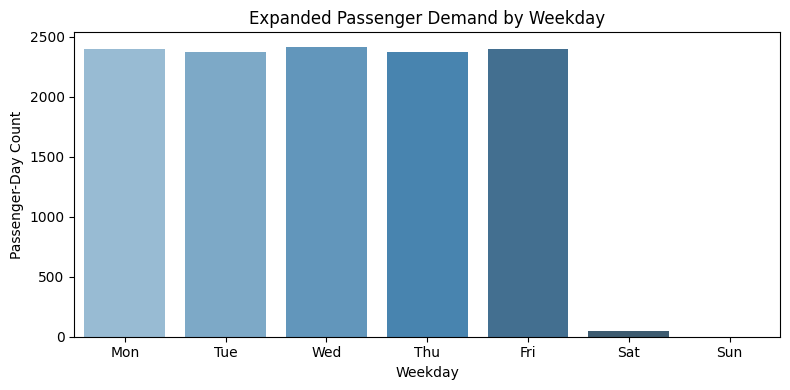

,weekday,passenger_day_count
0,Mon,2399
1,Tue,2374
2,Wed,2415
3,Thu,2375
4,Fri,2396
5,Sat,44
6,Sun,0


In [48]:
# 画图

# Expand day list to one row per passenger-day, then visualize weekly demand
if "day_list_parsed" in df.columns:
    day_col = "day_list_parsed"
else:
    day_col = "day_list"
# Keep a copy so downstream modules are not affected
df_expanded = df.copy().explode(day_col).rename(columns={day_col: "day_single"})
df_expanded = df_expanded.dropna(subset=["day_single"])
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_count = (
    df_expanded["day_single"]
    .value_counts()
    .reindex(weekday_order, fill_value=0)
    .rename_axis("weekday")
    .reset_index(name="passenger_day_count")
)
plt.figure(figsize=(8, 4))
sns.barplot(data=weekday_count, x="weekday", y="passenger_day_count", palette="Blues_d")
plt.title("Expanded Passenger Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Passenger-Day Count")
plt.tight_layout()
plt.show()
display(weekday_count)

In [50]:
today = pd.Timestamp.today()

expired = df[df["expiry_date"] < today]
active = df[df["expiry_date"] >= today]

print("已过期人数：", len(expired))
print("仍有效人数：", len(active))

已过期人数： 0
仍有效人数： 1258


In [51]:
df = passenger_input.copy()

route_counts = (
    df.groupby("existing_route")["passenger"]
    .count()
    .reset_index(name="total_passengers")
    .sort_values(by="total_passengers", ascending=False)
)

print(route_counts)

    existing_route  total_passengers
33          SR3002                22
174         SR3671                21
72          SR3191                21
32          SR3001                20
201         SR6042                19
..             ...               ...
147         SR3542                 2
18          SR1086                 2
81          SR3226                 1
69          SR3177                 1
78          SR3217                 1

[276 rows x 2 columns]


<Figure size 640x480 with 0 Axes>

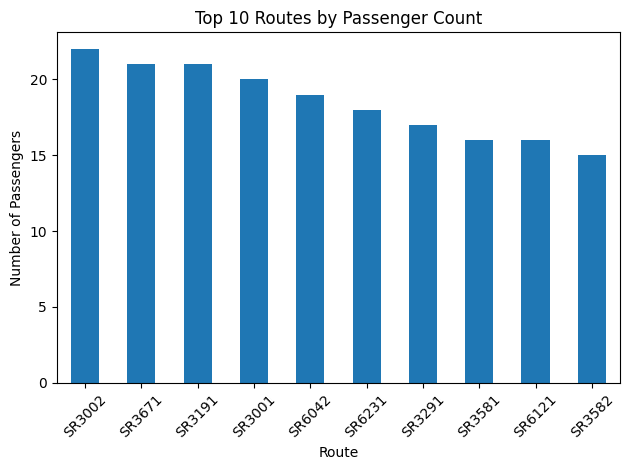

In [53]:
import matplotlib.pyplot as plt

top_n = 10

plt.figure()
route_counts.head(top_n).plot(
    x="existing_route",
    y="total_passengers",
    kind="bar",
    legend=False
)

plt.title(f"Top {top_n} Routes by Passenger Count")
plt.xlabel("Route")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
total_passengers = len(passenger_input)

print("总人数（含跟车）：", total_passengers)

总人数（含跟车）： 2506
